# Construct End-User HDF5 Files

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import uproot
import glob
import awkward as ak
import itertools
import yaml
import os
import sys
from tqdm import tqdm
from pathlib import Path
import atlasify as atl
from typing import List
import h5py
atl.ATLAS = "ColliderML"

sys.path.append("../")
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/scripts/postprocessing")
from pyedm4hep import EDM4hepEvent
from loading_utils import load_root_file
from convert_digihits import _merge_measurements_with_tracker, process_event_for_digihits, process_chunk_for_digihits,build_hdf5_digihits, process_run_for_digihits

## Roadmap

1. Load in edm4hep file
4. Load in measurements root
5. Load in trackstates ambi roo
8. Digihit object needs:
    - ...

# Explore

## Loading

In [7]:
base_dir = "/global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/"
event_num = 0

### 1. Load in edm4hep file

In [8]:
event = EDM4hepEvent(os.path.join(base_dir, "edm4hep.root"), event_index=event_num)

Loading event 0 from /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 701148 particles.
  Loaded 202101 tracker hits.
  Loaded 1018325 calo hits and 4751093 contributions.


In [45]:
tracker_df = event.get_tracker_hits_df()
tracker_df.columns

# Cast x,y,z to float32
tracker_df[["x", "y", "z"]] = tracker_df[["x", "y", "z"]].astype(np.float32)

# Sort by x,y,z
tracker_df = tracker_df.sort_values(by=["x", "y", "z"])

## DigiHits Objects

In [46]:
digihits_path = "/global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/measurements.root"
simhits_path = "/global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/simhits.root"

In [47]:
# uproot load digihits file

digihits_df = load_root_file(digihits_path)
simhits_df = load_root_file(simhits_path)

digihits_df = digihits_df[digihits_df.event_nr == 0]
simhits_df = simhits_df[simhits_df.event_id == 0]

# Cast true_x,true_y,true_z to float32
digihits_df[["true_x", "true_y", "true_z"]] = digihits_df[["true_x", "true_y", "true_z"]].astype(np.float32)

# Sort by true_x,true_y,true_z
digihits_df = digihits_df.sort_values(by=["true_x", "true_y", "true_z"])

In [48]:
digihits_df[["rec_x", "rec_y", "rec_z"]]

,rec_x,rec_y,rec_z
entry,,,
196878,-990.874084,-43.698357,2270.5
167740,-989.737732,13.111578,-1904.5
193188,-990.547729,27.381363,1625.5
165940,-991.261292,-63.057579,-2254.5
193171,-991.679932,62.472103,1604.5
...,...,...,...
191428,990.518616,25.927814,1320.5
167438,989.146179,42.686440,-1909.5
196556,990.028625,1.430596,2270.5


In [49]:
digihits_df[["true_x", "true_y", "true_z"]]

,true_x,true_y,true_z
entry,,,
196878,-1068.791138,-42.139557,2270.427734
167740,-1066.606079,14.651224,-1904.512695
193188,-1065.476685,25.929476,1625.500000
165940,-1065.399048,-61.599911,-2254.500000
193171,-1065.151855,73.616951,1604.525391
...,...,...,...
191428,1065.315308,24.288553,1320.500000
167438,1065.793213,44.278023,-1909.518555
196556,1065.943848,-0.174951,2270.500000


First, does digihits and simhits match up?

In [50]:
tracker_df[["x", "y", "z"]]

,x,y,z
190545,-1068.791138,-42.139557,2270.427734
184239,-1066.606079,14.651224,-1904.512695
197929,-1065.476685,25.929476,1625.500000
183081,-1065.399048,-61.599911,-2254.500000
195656,-1065.151855,73.616951,1604.525391
...,...,...,...
192396,1065.315308,24.288553,1320.500000
182858,1065.793213,44.278023,-1909.518555
194992,1065.943848,-0.174951,2270.500000
180375,1067.133667,-20.759151,-1304.450317


In [51]:
# Merge digihits_df with tracker_df on left=true_x,true_y,true_z right=x,y,z

merged = pd.merge(digihits_df, tracker_df, left_on=["true_x", "true_y", "true_z"], right_on=["x", "y", "z"], how="left")

In [52]:
merged

,event_nr,volume_id,layer_id,surface_id,extra_id,rec_loc0,rec_loc1,rec_time,var_loc0,var_loc1,...,pz,EDep,particle_id,detector,r,R,phi,theta,eta,pt
0,0,30,8,132,2,43.707096,NaN,NaN,0.005184,NaN,...,0.044535,0.000053,72641,LongStripEndcapReadout,1069.621569,2509.767295,-3.102186,0.440270,1.497176,0.071701
1,0,28,8,131,2,-13.114201,NaN,NaN,0.005184,NaN,...,-0.000186,0.000364,334764,LongStripEndcapReadout,1066.706643,2182.895203,3.127857,2.631033,-1.343335,0.000302
2,0,30,4,131,2,-27.386841,NaN,NaN,0.005184,NaN,...,1.666867,0.000113,27501,LongStripEndcapReadout,1065.792141,1943.749762,3.117261,0.580351,1.208637,1.089141
3,0,28,6,131,2,63.070190,NaN,NaN,0.005184,NaN,...,-1.213506,0.000099,50229,LongStripEndcapReadout,1067.178412,2494.321554,-3.083838,2.699488,-1.492878,0.662564
4,0,30,4,129,2,-67.516060,NaN,NaN,0.005184,NaN,...,-0.000276,0.000275,345300,LongStripEndcapReadout,1067.692853,1927.295968,3.072588,0.587143,1.196314,0.000114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202093,0,30,2,98,2,25.933001,NaN,NaN,0.005184,NaN,...,0.954179,0.000124,61722,LongStripEndcapReadout,1065.592131,1696.822572,0.022795,0.678971,1.040839,0.802868
202094,0,28,8,98,2,42.694981,NaN,NaN,0.005184,NaN,...,0.018524,0.000002,264388,LongStripEndcapReadout,1066.712570,2187.266991,0.041521,2.632149,-1.345621,0.013690
202095,0,30,8,98,2,1.430882,NaN,NaN,0.005184,NaN,...,1.313447,0.000119,45020,LongStripEndcapReadout,1065.943861,2508.267642,-0.000164,0.438931,1.500322,0.708167
202096,0,28,12,97,2,-19.242596,NaN,NaN,0.005184,NaN,...,-0.010930,0.000020,95649,LongStripEndcapReadout,1067.335607,1685.466111,-0.019451,2.455836,-1.030080,0.010992


In [53]:
merged["res_x"] = merged.rec_x - merged.true_x
merged["res_y"] = merged.rec_y - merged.true_y
merged["res_z"] = merged.rec_z - merged.true_z

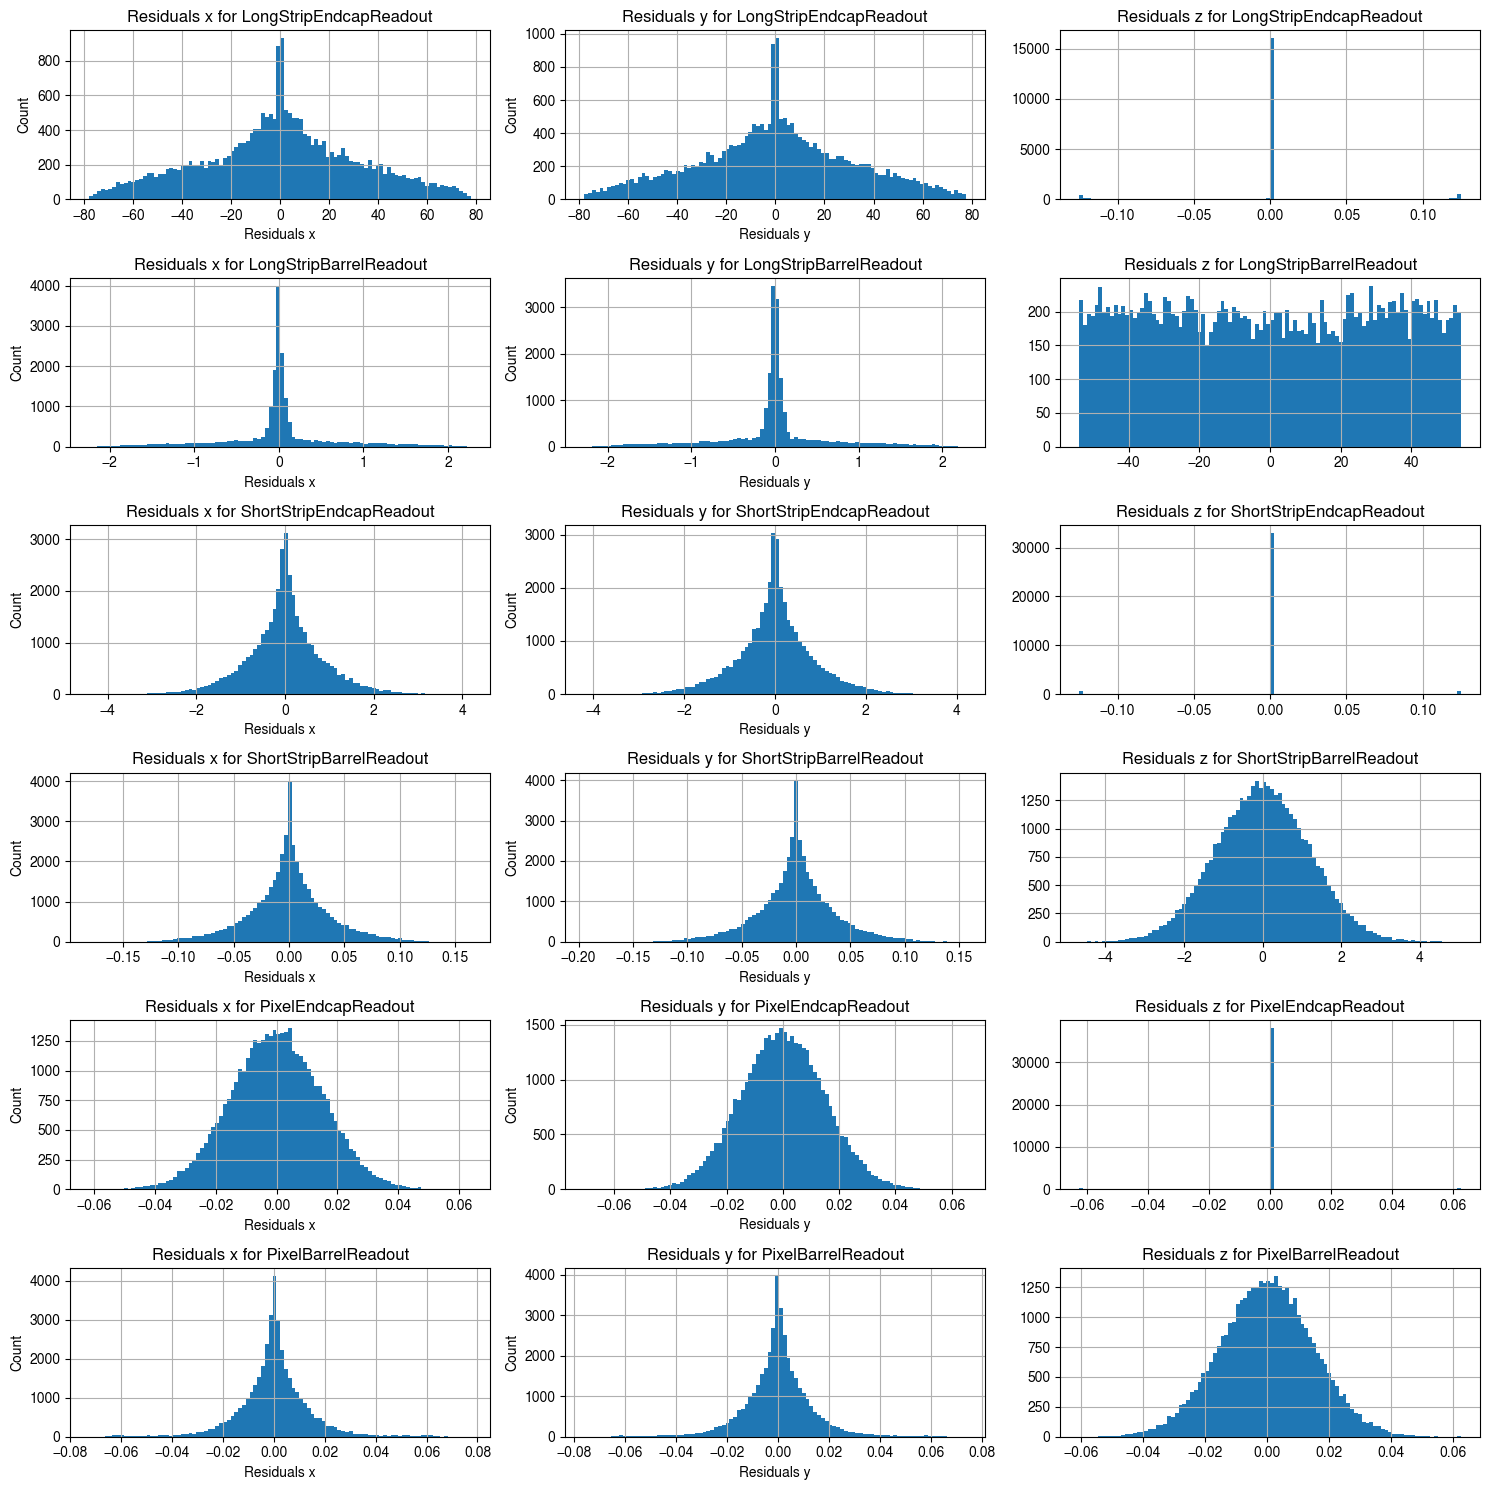

In [54]:
num_regions = len(merged.detector.unique())

fig, axs = plt.subplots(num_regions, 3, figsize=(15, 15))

for i, region in enumerate(merged.detector.unique()):
    merged_region = merged[merged.detector == region]
    merged_region.res_x.hist(ax=axs[i, 0], bins=100)
    merged_region.res_y.hist(ax=axs[i, 1], bins=100)
    merged_region.res_z.hist(ax=axs[i, 2], bins=100)
    # title and axes labels
    axs[i, 0].set_title(f"Residuals x for {region}")
    axs[i, 0].set_xlabel("Residuals x")
    axs[i, 0].set_ylabel("Count")
    axs[i, 1].set_title(f"Residuals y for {region}")
    axs[i, 1].set_xlabel("Residuals y")
    axs[i, 1].set_ylabel("Count")
    axs[i, 2].set_title(f"Residuals z for {region}")
    # break

plt.tight_layout()
plt.show()


# Test Script

In [2]:
edm4hep_path = "/global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root"
digihits_path = "/global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/measurements.root"

edm4hep_file = EDM4hepEvent(edm4hep_path, event_index=0)
digihits_df = load_root_file(digihits_path)

simhits_df = edm4hep_file.get_tracker_hits_df()
# digihits_df = digihits_df[digihits_df.event_nr == 0]

Loading event 0 from /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 701148 particles.
  Loaded 202101 tracker hits.
  Loaded 1018325 calo hits and 4751093 contributions.


In [4]:
digihits_df

,event_nr,volume_id,layer_id,surface_id,extra_id,rec_loc0,rec_loc1,rec_time,var_loc0,var_loc1,...,true_y,true_z,true_incident_phi,true_incident_theta,residual_loc0,residual_loc1,residual_time,pull_loc0,pull_loc1,pull_time
entry,,,,,,,,,,,,,,,,,,,,,
0,0,16,4,1,1,-10.688817,30.646891,416.615173,0.000225,0.000225,...,10.675945,-1515.599976,-1.551392,-2.189853,NaN,NaN,NaN,NaN,NaN,NaN
1,0,16,4,1,1,-6.924357,17.379297,3110.463867,0.000225,0.000225,...,6.940556,-1515.599976,-1.624928,-1.526175,NaN,NaN,NaN,NaN,NaN,NaN
2,0,16,4,1,1,-10.769912,-6.057911,425.481537,0.000225,0.000225,...,10.749805,-1515.599976,-1.580868,-1.524993,NaN,NaN,NaN,NaN,NaN,NaN
3,0,16,4,1,1,6.308127,-26.472202,1488.979492,0.000225,0.000225,...,-6.311029,-1515.599976,-1.568406,-1.536964,NaN,NaN,NaN,NaN,NaN,NaN
4,0,16,4,1,1,-9.805357,-18.170237,1123.066528,0.000225,0.000225,...,9.800987,-1515.599976,-1.581483,-1.532947,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1982191,7,30,12,192,2,-3.286438,NaN,NaN,0.005184,NaN,...,892.851746,3009.500000,1.740870,1.288979,NaN,NaN,NaN,NaN,NaN,NaN
1982192,7,30,12,192,2,23.976496,NaN,NaN,0.005184,NaN,...,932.825928,3009.500000,-2.325722,-1.448778,NaN,NaN,NaN,NaN,NaN,NaN
1982193,7,30,12,192,2,-15.848466,NaN,NaN,0.005184,NaN,...,866.964294,3009.500000,-0.665980,-0.406895,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
simhits_df

,cellID,time,pathLength,quality,x,y,z,px,py,pz,EDep,particle_id,detector,r,R,phi,theta,eta,pt
0,18485942029830,0.632519,1.242103,0,23.371382,-21.980095,-312.803495,6.697474e-02,-0.084904,-1.030470,0.000578,71754,PixelBarrelReadout,32.083424,314.444546,-0.754730,3.039383,-2.973003,0.108140
1,13675511549446,0.643041,0.290332,0,23.201246,-22.196886,-316.335669,-1.270192e-03,0.000176,-0.000969,0.000160,71816,PixelBarrelReadout,32.109183,317.961090,-0.763278,3.040436,-2.983375,0.001282
2,11200654085638,0.656863,0.196210,0,21.464867,-24.409424,-318.198011,3.364457e-04,-0.001148,-0.000879,0.000059,71816,PixelBarrelReadout,32.504776,319.853927,-0.849498,3.039793,-2.977033,0.001196
3,13400315135238,-0.281970,0.154551,0,-12.156777,29.827301,-26.499969,-2.728385e-01,0.707195,-0.533034,0.000073,71749,PixelBarrelReadout,32.209550,41.709752,1.957813,2.259248,-0.750324,0.758001
4,259827788286486,-0.132340,0.155757,0,-24.450725,63.921562,-52.067231,-2.406966e-01,0.716927,-0.533676,0.000048,71749,PixelBarrelReadout,68.438323,85.993026,1.936136,2.221168,-0.701757,0.756253
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202096,16080358715470,6.552033,0.261402,0,-702.881442,-347.505711,2579.500000,-1.311453e+00,-0.256972,4.377242,0.000192,275,LongStripEndcapReadout,784.093452,2696.038351,-2.682434,0.295096,1.906308,1.336392
202097,16097538588750,6.590414,0.261383,0,-706.176283,-348.148114,2590.500000,-1.311427e+00,-0.254098,4.377254,0.000114,275,LongStripEndcapReadout,787.332237,2707.504811,-2.683557,0.295059,1.906435,1.335816
202098,16119012376654,6.607859,0.261366,0,-707.674458,-348.436740,2595.500000,-1.311264e+00,-0.249679,4.376379,0.000075,275,LongStripEndcapReadout,788.803715,2712.716637,-2.684069,0.295042,1.906494,1.334823
202099,15895675101534,73.599731,0.000333,0,-903.713027,302.701627,3020.458821,4.036334e-03,0.026423,0.014916,0.000072,700377,LongStripEndcapReadout,953.061126,3167.253858,2.818385,0.305648,1.870642,0.026730


In [8]:
hits = _merge_measurements_with_tracker(digihits_df, simhits_df)

In [16]:
hits = process_event_for_digihits(0, 0, digihits_df, simhits_df)

In [17]:
hits

,x,y,z,true_x,true_y,true_z,time,px,py,pz,particle_id,cell_id,detector,e_dep,path_length,event_id
0,106.611557,10.689144,-1515.599976,106.617691,10.675945,-1515.599976,1.359013,-0.169783,-0.004625,-0.238297,540262,65129152615,PixelEndcapReadout,0.000039,0.153478,0
1,93.369598,6.928734,-1515.599976,93.357452,6.940556,-1515.599976,10.239325,0.031376,0.038075,-0.702686,461597,66387443815,PixelEndcapReadout,0.000039,0.125309,0
2,69.929230,10.756277,-1515.599976,69.923332,10.749805,-1515.599976,1.516471,0.433610,0.095283,-9.460220,44796,65112375399,PixelEndcapReadout,0.000029,0.125138,0
3,49.519321,-6.293961,-1515.599976,49.548458,-6.311029,-1515.599976,4.859240,0.406038,-0.028683,-11.996787,40423,2113929319,PixelEndcapReadout,0.000028,0.125072,0
4,57.812122,9.795135,-1515.599976,57.820751,9.800987,-1515.599976,3.783754,0.277756,0.078387,-7.334937,69172,65431142503,PixelEndcapReadout,0.000041,0.125097,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202093,420.610748,898.316040,3009.500000,393.917908,829.851501,3009.500000,15.198336,0.324349,0.051358,0.803515,249968,1284196307294,LongStripEndcapReadout,0.000369,0.270114,0
202094,397.485901,907.357178,3009.500000,414.054474,949.608887,3009.500000,10.770111,-0.442796,0.136513,0.806776,70267,575526703454,LongStripEndcapReadout,0.000061,0.288310,0
202095,389.316895,910.551086,3009.500000,413.665619,972.792358,3009.500000,7.939838,0.010319,-0.019559,0.465902,266576,322123632990,LongStripEndcapReadout,0.000074,0.250286,0
202096,430.794800,894.334412,3009.500000,418.645782,863.071899,3009.500000,15.444677,0.000270,0.000649,0.002324,190927,1597728919902,LongStripEndcapReadout,0.000132,0.275842,0


In [10]:
hits["res_x"] = hits.x - hits.true_x
hits["res_y"] = hits.y - hits.true_y
hits["res_z"] = hits.z - hits.true_z

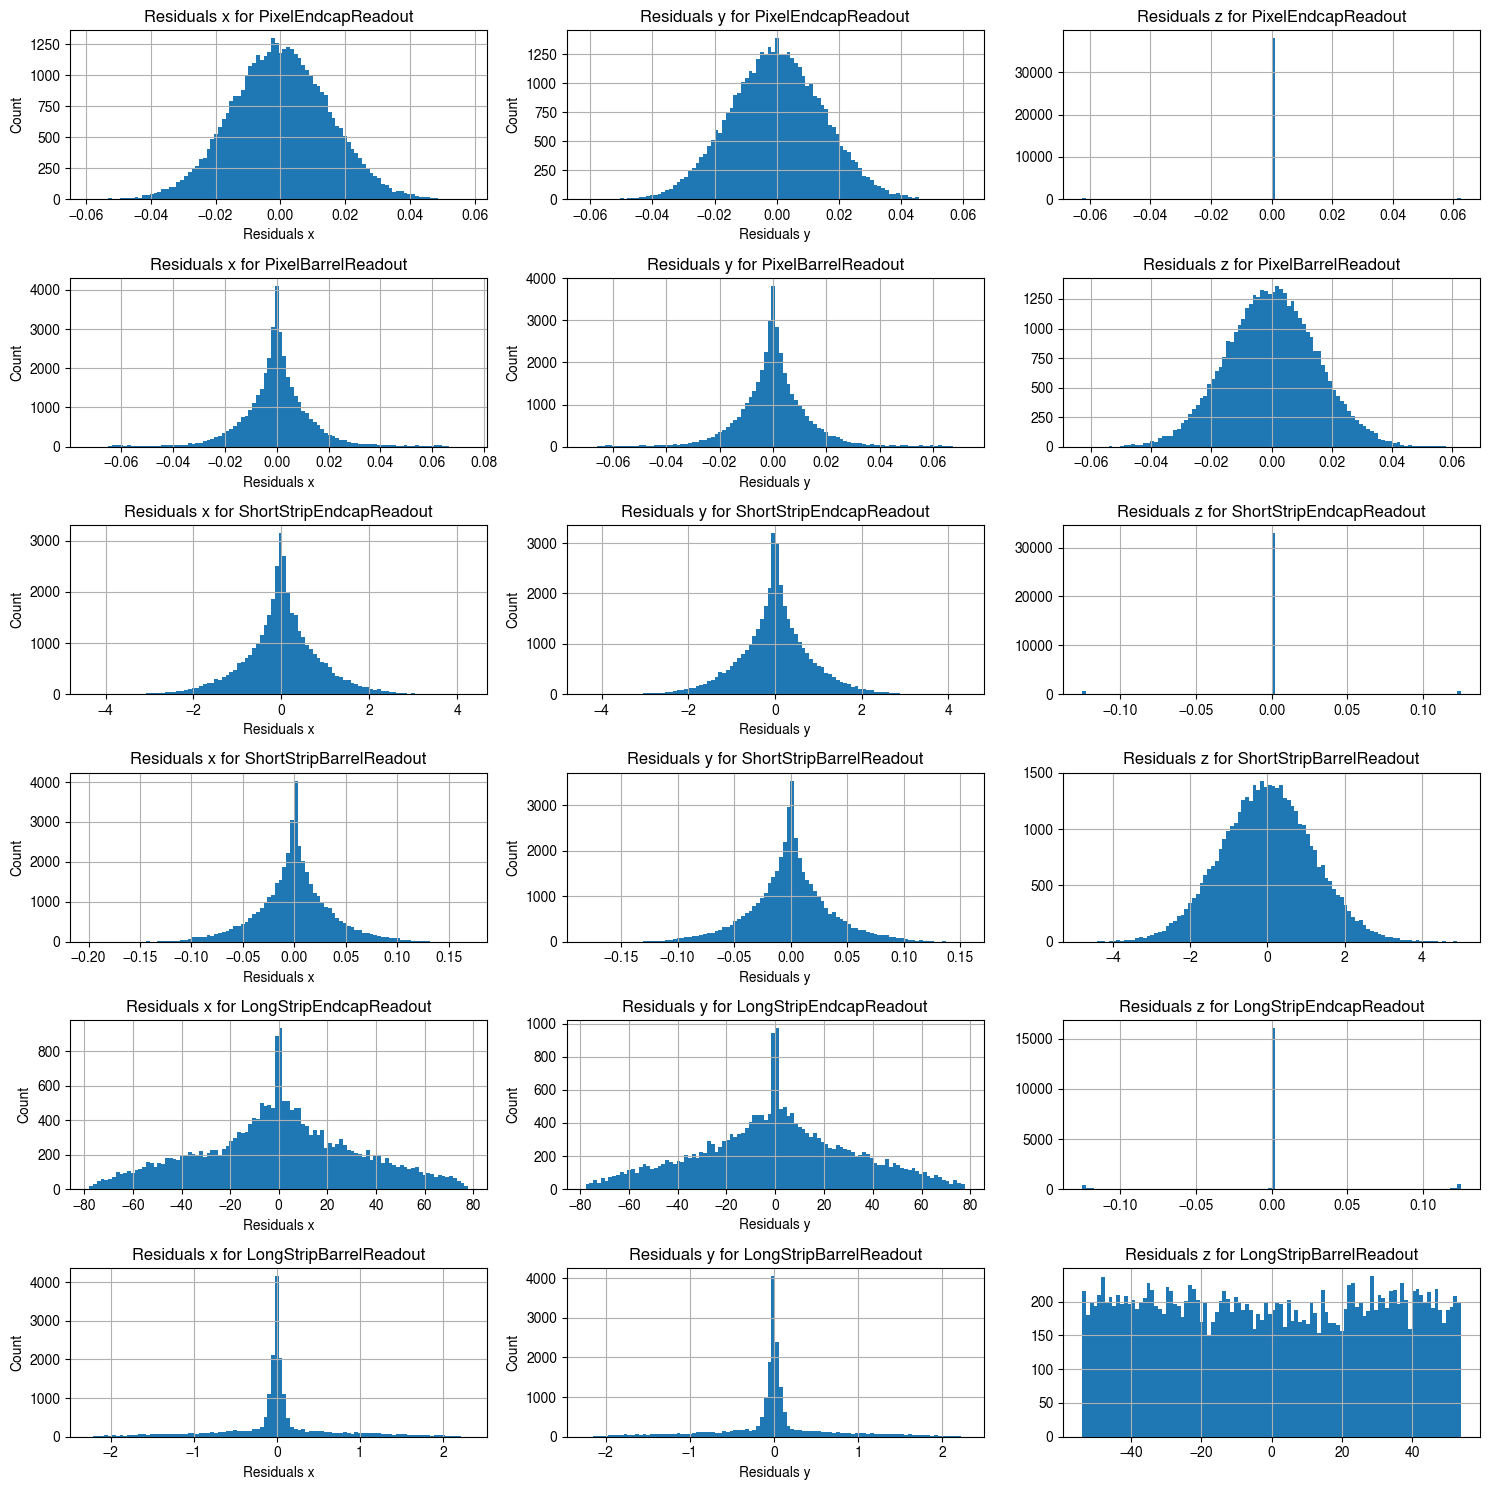

In [11]:
num_regions = len(hits.detector.unique())

fig, axs = plt.subplots(num_regions, 3, figsize=(15, 15))

for i, region in enumerate(hits.detector.unique()):
    hits_region = hits[hits.detector == region]
    hits_region.res_x.hist(ax=axs[i, 0], bins=100)
    hits_region.res_y.hist(ax=axs[i, 1], bins=100)
    hits_region.res_z.hist(ax=axs[i, 2], bins=100)
    # title and axes labels
    axs[i, 0].set_title(f"Residuals x for {region}")
    axs[i, 0].set_xlabel("Residuals x")
    axs[i, 0].set_ylabel("Count")
    axs[i, 1].set_title(f"Residuals y for {region}")
    axs[i, 1].set_xlabel("Residuals y")
    axs[i, 1].set_ylabel("Count")
    axs[i, 2].set_title(f"Residuals z for {region}")
    # break

plt.tight_layout()
plt.show()


In [5]:
digihits_df.columns

Index(['event_nr', 'volume_id', 'layer_id', 'surface_id', 'extra_id',
       'rec_loc0', 'rec_loc1', 'rec_time', 'var_loc0', 'var_loc1', 'var_time',
       'rec_x', 'rec_y', 'rec_z', 'clus_size', 'clus_size_loc0',
       'clus_size_loc1', 'true_loc0', 'true_loc1', 'true_phi', 'true_theta',
       'true_qop', 'true_time', 'true_x', 'true_y', 'true_z',
       'true_incident_phi', 'true_incident_theta', 'residual_loc0',
       'residual_loc1', 'residual_time', 'pull_loc0', 'pull_loc1',
       'pull_time'],
      dtype='object')

In [9]:
simhits_df.columns

Index(['cellID', 'time', 'pathLength', 'quality', 'x', 'y', 'z', 'px', 'py',
       'pz', 'EDep', 'particle_id', 'detector', 'r', 'R', 'phi', 'theta',
       'eta', 'pt'],
      dtype='object')

<Axes: xlabel='EDep', ylabel='Count'>

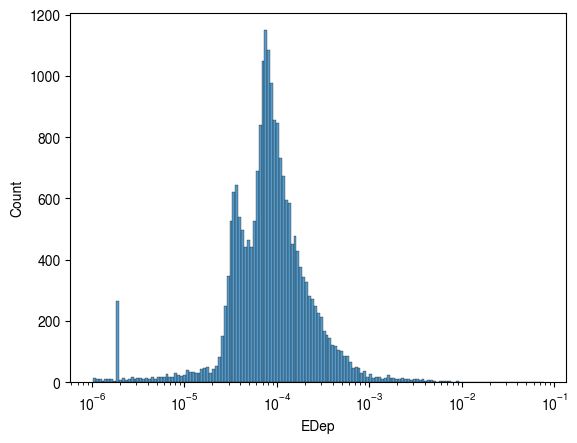

In [20]:
sns.histplot(simhits_df.EDep, log_scale=True)

<Axes: xlabel='pathLength', ylabel='Count'>

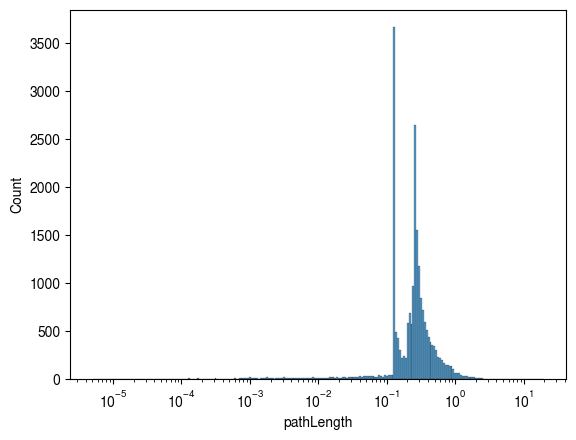

In [21]:
sns.histplot(simhits_df.pathLength, log_scale=True)

In [9]:
all_hits_df = process_run_for_digihits(
    "/global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0",0,8)

Processing events:   0%|          | 0/8 [00:00<?, ?it/s]

Loading event 0 from /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 701148 particles.
  Loaded 202101 tracker hits.
  Loaded 1018325 calo hits and 4751093 contributions.


Processing events:  12%|█▎        | 1/8 [00:04<00:28,  4.01s/it]

Loading event 1 from /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 842073 particles.
  Loaded 238809 tracker hits.
  Loaded 1213290 calo hits and 5773372 contributions.


Processing events:  25%|██▌       | 2/8 [00:08<00:25,  4.30s/it]

...

Processing events:  75%|███████▌  | 6/8 [00:28<00:09,  4.89s/it]

Loading event 6 from /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 940868 particles.
  Loaded 266801 tracker hits.
  Loaded 1332704 calo hits and 6429712 contributions.


Processing events:  88%|████████▊ | 7/8 [00:33<00:05,  5.20s/it]

Loading event 7 from /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 989128 particles.
  Loaded 275536 tracker hits.
  Loaded 1374591 calo hits and 6785985 contributions.


Processing events: 100%|██████████| 8/8 [00:38<00:00,  4.81s/it]


In [10]:
all_hits_df

[                 x           y            z      true_x      true_y  \
 0       106.646889   10.688817 -1515.599976  106.617691   10.675945   
 1        93.379295    6.924357 -1515.599976   93.357452    6.940556   
 2        69.942085   10.769912 -1515.599976   69.923332   10.749805   
 3        49.527798   -6.308127 -1515.599976   49.548458   -6.311029   
 4        57.829762    9.805357 -1515.599976   57.820751    9.800987   
 ...            ...         ...          ...         ...         ...   
 202093  420.657867  898.297607  3009.500000  393.917908  829.851501   
 202094  397.422211  907.382080  3009.500000  414.054474  949.608887   
 202095  389.430939  910.506470  3009.500000  413.665619  972.792358   
 202096  430.868896  894.305420  3009.500000  418.645782  863.071899   
 202097  372.269379  917.216125  3009.500000  385.536163  951.183655   
 
              true_z       time        px        py         pz  particle_id  \
 0      -1515.599976   1.359013 -0.169783 -0.004625  -0

In [11]:
all_hits_df = pd.concat(all_hits_df, ignore_index=True)

In [15]:
# Get column types of all_hits_df
print(all_hits_df.dtypes)

x              float32
y              float32
z              float32
true_x         float64
true_y         float64
true_z         float64
time           float32
px             float32
py             float32
pz             float32
particle_id      int32
cell_id         uint64
detector        object
e_dep          float32
path_length    float32
event_id         int64
dtype: object


In [17]:
print(all_hits_df['detector'].unique())
print(type(all_hits_df['detector'].iloc[0]))

# Convert detector column from strings to integers
detector_mapping = {
    'PixelBarrelReadout': 0,
    'PixelEndcapReadout': 1, 
    'ShortStripBarrelReadout': 2,
    'ShortStripEndcapReadout': 3,
    'LongStripBarrelReadout': 4,
    'LongStripEndcapReadout': 5
}

all_hits_df['detector'] = all_hits_df['detector'].map(detector_mapping)
print("After conversion:")
print(all_hits_df['detector'].unique())
print(all_hits_df.dtypes)

['PixelEndcapReadout' 'PixelBarrelReadout' 'ShortStripEndcapReadout'
 'ShortStripBarrelReadout' 'LongStripEndcapReadout'
 'LongStripBarrelReadout']
<class 'str'>
After conversion:
[1 0 3 2 5 4]
x              float32
y              float32
z              float32
true_x         float64
true_y         float64
true_z         float64
time           float32
px             float32
py             float32
pz             float32
particle_id      int32
cell_id         uint64
detector         int64
e_dep          float32
path_length    float32
event_id         int64
dtype: object


In [19]:
output_dir = "/global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0"
dataset_name = "full_pileup_mini_pilot.ttbar.v4"
output_file = f"{output_dir}/{dataset_name}.h5"

# Remove existing file if it exists to avoid group conflicts
import os
if os.path.exists(output_file):
    os.remove(output_file)
    print(f"Removed existing file: {output_file}")

with h5py.File(output_file, 'a') as f:
    events_group = f.create_group('events') if 'events' not in f else f['events']

    for event_id, event_df in tqdm(all_hits_df.groupby('event_id')):
        event_group = events_group.create_group(f'event_{event_id}')

        # Drop event_id for storage
        data_df = event_df.drop(columns=['event_id'], errors='ignore')

        event_group.create_dataset(
            'measurements',
            data=data_df.to_records(index=False)
        )

Removed existing file: /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/full_pileup_mini_pilot.ttbar.v4.h5


  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 27.38it/s]


In [23]:
process_chunk_for_digihits(
    run_dirs=["/global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0"],
    start_run=0,
    runs_per_chunk=1,
    output_dir="/global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0",
    dataset_name="full_pileup_mini_pilot.ttbar.v4",
    run_size=8,
    force_overwrite=True
)

Processing runs:   0%|          | 0/1 [00:00<?, ?it/s]

Loading event 0 from /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 701148 particles.
  Loaded 202101 tracker hits.
  Loaded 1018325 calo hits and 4751093 contributions.


Loading event 1 from /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 842073 particles.
  Loaded 238809 tracker hits.
  Loaded 1213290 calo hits and 5773372 contributions.


Loading event 2 from /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 836691 particles.
  Loaded 234264 tracker hits.
  Loaded 1198869 calo hits and 5726718 contributions.


Loading event 3 from /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 927839 particles.
  Loaded 261053 tracker hits.
  Loaded 1311801 calo hits and 6392608 contributions.


Loading event 4 from /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 828148 particles.
  Loaded 225773 tracker hits.
  Loaded 1153516 calo hits and 5694834 contributions.


Loading event 5 from /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 1000634 particles.
  Loaded 277940 tracker hits.
  Loaded 1402864 calo hits and 6839004 contributions.


Loading event 6 from /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 940868 particles.
  Loaded 266801 tracker hits.
  Loaded 1332704 calo hits and 6429712 contributions.


Loading event 7 from /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 989128 particles.
  Loaded 275536 tracker hits.
  Loaded 1374591 calo hits and 6785985 contributions.


Processing events: 100%|██████████| 8/8 [00:37<00:00,  4.68s/it]
2025-08-15 03:53:31,347 - INFO - Writing 1982220 measurements across 8 events -> /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/full_pileup_mini_pilot.ttbar.v4.reco.tracker_hits.events0-7.h5


## Test HDF5 file

In [ ]:
h5_path = "/global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/full_pileup_mini_pilot.ttbar.v4.reco.tracker_hits.events0-7.h5"

In [ ]:
# Test loading of h5 file



## Debug

In [26]:
#!/usr/bin/env python3
"""
Convert digitized tracker measurements (measurements.root) to HDF5 format.

This merges measurements with EDM4hep tracker hits to attach detector labels
and truth particle links, using the true_x/true_y/true_z coordinates present
in the measurements file to match to EDM4hep hit x/y/z.
"""

import argparse
import yaml
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd
import h5py
import uproot
from tqdm import tqdm
import logging
import sys

# Use relative imports to avoid conflicts with other utils modules
from utils.path_utils import get_run_paths, ensure_output_dir, get_chunk_info
from utils.track_utils import load_root_file

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent


logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)


def _merge_measurements_with_tracker(meas_df: pd.DataFrame, tracker_df: pd.DataFrame, include_meas_cols: List[str] = [], include_simhits_cols: List[str] = []) -> pd.DataFrame:
    """
    Merge measurements and EDM4hep tracker hits by coordinate matching.

    Strategy: cast both coordinate sets to float32 and merge on equality.
    This mirrors the notebook exploration where float32 alignment produced
    exact matches. If columns are missing, the merge safely degrades.
    """
    # Guard on required columns
    coord_meas = [c for c in ["true_x", "true_y", "true_z"] if c in meas_df.columns]
    coord_trk = [c for c in ["x", "y", "z"] if c in tracker_df.columns]
    if len(coord_meas) != 3 or len(coord_trk) != 3:
        return meas_df

    # Cast to float32 for stable equality
    meas_df = meas_df.copy()
    tracker_df = tracker_df.copy()
    meas_df.loc[:, ["true_x", "true_y", "true_z"]] = meas_df[["true_x", "true_y", "true_z"]].astype(np.float32)
    tracker_df.loc[:, ["x", "y", "z"]] = tracker_df[["x", "y", "z"]].astype(np.float32)

    # Select minimal simulation hits columns to append
    if not include_simhits_cols:
        include_simhits_cols = [
            "x", "y", "z", "time", "px", "py", "pz", "particle_id", "cellID", "detector", "EDep", "pathLength"
        ]
    rhs = tracker_df[include_simhits_cols].copy()

    # Select minimal measurement columns to append
    if not include_meas_cols:
        include_meas_cols = [
            "true_x", "true_y", "true_z", "rec_x", "rec_y", "rec_z"
        ]
    lhs = meas_df[include_meas_cols].copy()

    merged = pd.merge(
        lhs,
        rhs,
        left_on=["true_x", "true_y", "true_z"],
        right_on=["x", "y", "z"],
        how="left"
    )

    # Drop the original true_x, true_y, true_z from measurements (now duplicated)
    merged = merged.drop(columns=["true_x", "true_y", "true_z"])

    # Rename columns to match final naming convention
    # Simhits x,y,z become true_x, true_y, true_z
    # Measurements rec_x, rec_y, rec_z become x, y, z
    merged = merged.rename(columns={
        "x": "true_x",
        "y": "true_y", 
        "z": "true_z",
        "rec_x": "x",
        "rec_y": "y",
        "rec_z": "z",
        "cellID": "cell_id",
        "EDep": "e_dep",
        "pathLength": "path_length"
    })

    return merged


def process_event_for_digihits(event_id: int, local_event_num: int, measurements_df: pd.DataFrame, tracker_df: pd.DataFrame | None) -> pd.DataFrame:
    """
    Build per-event digitized measurements dataframe, merged with tracker.
    """
    print(measurements_df.head())
    print(tracker_df.head())
    # Filter event slice
    if "event_nr" in measurements_df.columns:
        ev_meas = measurements_df[measurements_df.event_nr == local_event_num].copy()
    else:
        # Assume the file is already a single-event view
        ev_meas = measurements_df.copy()

    measurements_length = len(ev_meas)
    event_measurements = _merge_measurements_with_tracker(ev_meas, tracker_df)
    merged_length = len(event_measurements)
    logging.debug(
        f"Event {event_id}: merged measurements {measurements_length} -> {merged_length}"
    )

    # Event id is the global id passed in
    event_measurements["event_id"] = event_id
    return event_measurements


def build_hdf5_digihits(df: pd.DataFrame, output_file: str) -> None:
    """
    Write digitized measurements to HDF5 under /events/event_#/measurements.
    Uses a structured dtype inferred from dataframe dtypes, with utf8 strings.
    """
    # Prepare string dtype helper
    str_dtype = h5py.string_dtype(encoding='utf8')

    with h5py.File(output_file, 'a') as f:
        events_group = f.create_group('events') if 'events' not in f else f['events']

        for event_id, event_df in df.groupby('event_id'):
            event_group = events_group.create_group(f'event_{event_id}')

            # Drop event_id for storage
            data_df = event_df.drop(columns=['event_id'], errors='ignore')

            # Build a safe dtype mapping
            name_to_dtype = {}
            for name, series in data_df.items():
                if pd.api.types.is_integer_dtype(series):
                    name_to_dtype[name] = np.int64
                elif pd.api.types.is_float_dtype(series):
                    name_to_dtype[name] = np.float64
                elif pd.api.types.is_bool_dtype(series):
                    name_to_dtype[name] = np.int8
                else:
                    name_to_dtype[name] = str_dtype

            dt = np.dtype([(n, t) for n, t in name_to_dtype.items()])
            out = np.empty(len(data_df), dtype=dt)
            for name in data_df.columns:
                target_t = name_to_dtype[name]
                if isinstance(target_t, h5py.Datatype) or target_t == str_dtype:
                    out[name] = data_df[name].astype(str).values
                else:
                    out[name] = np.asarray(data_df[name].values, dtype=target_t)

            event_group.create_dataset(
                'measurements',
                data=out,
                compression='gzip',
                compression_opts=9
            )


def process_run_for_digihits(run_dir: Path, run_number: int, run_size: int) -> List[pd.DataFrame]:
    """
    Process all events in a run directory into a list of dataframes.
    """
    run_dir = Path(run_dir)
    measurements_path = run_dir / "measurements.root"
    edm4hep_path = run_dir / "edm4hep.root"

    if not measurements_path.exists():
        logging.warning(f"Missing measurements file: {measurements_path}")
        return []


    meas_df = load_root_file(str(measurements_path))

    # If EDM4hep exists, we will merge per-event with tracker
    edm_available = edm4hep_path.exists()

    run_events: List[pd.DataFrame] = []
    for local_event_num in tqdm(range(run_size), desc="Processing events"):
        global_event_num = run_number * run_size + local_event_num

        tracker_df = None
        if edm_available:
            try:
                event = EDM4hepEvent(str(edm4hep_path), event_index=local_event_num)
                tracker_df = event.get_tracker_hits_df()
            except Exception as e:
                logging.warning(f"Failed to load tracker for event {local_event_num} in {run_dir}: {e}")

        ev_df = process_event_for_digihits(global_event_num, local_event_num, meas_df, tracker_df)
        print(ev_df.head())
        if not ev_df.empty:
            run_events.append(ev_df)
        
        print(len(run_events))

    return run_events


def process_chunk_for_digihits(
    run_dirs: List[Path],
    start_run: int,
    runs_per_chunk: int,
    output_dir: Path,
    dataset_name: str,
    run_size: int,
) -> None:
    """
    Process a chunk of runs and write one HDF5 file for the chunk.

    Args:
        run_dirs: List of run directories to process
        start_run: Index of the first run to process
        runs_per_chunk: Number of runs to process in each chunk
        output_dir: Directory to write the output HDF5 file
        dataset_name: Name of the dataset
        run_size: Number of events per run

    Returns:
        None
    """
    start_event = start_run * run_size
    end_run = min(start_run + runs_per_chunk, len(run_dirs))
    end_event = (end_run * run_size) - 1

    output_file = Path(output_dir) / f"{dataset_name}.reco.tracker_hits.events{start_event}-{end_event}.h5"
    if output_file.exists():
        logging.info(f"Skipping events {start_event}-{end_event} - exists: {output_file}")
        return

    all_event_dfs: List[pd.DataFrame] = []
    total_rows = 0
    for run_idx, run_dir in enumerate(tqdm(run_dirs[start_run:end_run], desc="Processing runs", leave=False)):
        try:
            evs = process_run_for_digihits(run_dir, start_run + run_idx, run_size)
            all_event_dfs.extend(evs)
            total_rows += sum(len(df) for df in evs)
        except Exception as e:
            logging.error(f"Error processing run {start_run + run_idx}: {e}")

    if all_event_dfs:
        all_df = pd.concat(all_event_dfs, ignore_index=True)
        logging.info(f"Writing {len(all_df)} measurements across {all_df.event_id.nunique()} events -> {output_file}")
        build_hdf5_digihits(all_df, str(output_file))
    else:
        logging.warning(f"No data to save for events {start_event}-{end_event}")


def convert_digihits(
    base_dir: Path | str,
    output_base_dir: Path | str,
    dataset_name: str,
    chunk_size: int = 1000,
    run_size: int = 10,
) -> None:
    """
    Convert digitized measurements to HDF5 files grouped by event.
    """
    base_dir = Path(base_dir)
    output_base_dir = Path(output_base_dir)

    run_dirs = get_run_paths(base_dir)
    num_runs = len(run_dirs)

    num_events, runs_per_chunk, num_chunks = get_chunk_info(num_runs, run_size, chunk_size)
    logging.info(f"Processing {num_runs} runs ({num_events} events), {runs_per_chunk} runs/chunk, {num_chunks} chunks")

    output_dir = ensure_output_dir(str(output_base_dir), dataset_name)
    dataset_name = dataset_name.replace("/", ".")

    for start_run in tqdm(range(0, num_runs, runs_per_chunk), desc="Processing chunks"):
        process_chunk_for_digihits(
            run_dirs,
            start_run,
            runs_per_chunk,
            Path(output_dir),
            dataset_name,
            run_size,
        )


def main():
    # Align CLI/config handling and file naming with convert_tracks.py
    parser = argparse.ArgumentParser(description="Convert EDM4HEP digitized tracker measurements to HDF5")
    parser.add_argument(
        "--config",
        help="Path to YAML config file",
        type=str,
        required=True
    )
    args = parser.parse_args()

    with open(args.config) as f:
        config = yaml.safe_load(f)

    campaign = config["campaign"]
    dataset = config["dataset"]
    version = config["version"]

    input_base_dir = Path(config["common"]["output_base_dir"]) / campaign / dataset / version
    output_base_dir = Path(config["common"]["staging_dir"])
    output_path = config.get("output_path", f"{campaign}/{dataset}/{version}/reco/digihits")

    chunk_size = config.get("chunk_size", 1000)
    run_size = config.get("run_size", 10)

    logging.info("\nStarting digitized hit conversion with configuration:")
    logging.info(f"Campaign: {campaign}, Dataset: {dataset}, Version: {version}")
    logging.info(f"Input directory: {input_base_dir}")
    logging.info(f"Output directory: {output_base_dir}/{output_path}")
    logging.info(f"Chunk size: {chunk_size}, Run size: {run_size}")

    convert_digihits(
        input_base_dir,
        output_base_dir,
        output_path,
        chunk_size,
        run_size,
    )



In [27]:
run_size = 8
run_number = 0
run_dir = "/global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0"
run_dir = Path(run_dir)
measurements_path = run_dir / "measurements.root"
edm4hep_path = run_dir / "edm4hep.root"

if not measurements_path.exists():
    logging.warning(f"Missing measurements file: {measurements_path}")
    # return []


meas_df = load_root_file(str(measurements_path))


# If EDM4hep exists, we will merge per-event with tracker
edm_available = edm4hep_path.exists()

run_events: List[pd.DataFrame] = []
for local_event_num in tqdm(range(run_size), desc="Processing events"):
    global_event_num = run_number * run_size + local_event_num

    tracker_df = None
    if edm_available:
        try:
            event = EDM4hepEvent(str(edm4hep_path), event_index=local_event_num)
            tracker_df = event.get_tracker_hits_df()
        except Exception as e:
            logging.warning(f"Failed to load tracker for event {local_event_num} in {run_dir}: {e}")

    ev_df = process_event_for_digihits(global_event_num, local_event_num, meas_df, tracker_df)
    print(ev_df.head())
    if not ev_df.empty:
        run_events.append(ev_df)
    
    print(len(run_events))
    break

Processing events:   0%|          | 0/8 [00:00<?, ?it/s]

Loading event 0 from /global/cfs/cdirs/m4958/data/ColliderML/public/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 701148 particles.
  Loaded 202101 tracker hits.
  Loaded 1018325 calo hits and 4751093 contributions.


Processing events:   0%|          | 0/8 [00:05<?, ?it/s]

       event_nr  volume_id  layer_id  surface_id  extra_id   rec_loc0  \
entry                                                                   
0             0         16         4           1         1 -10.688817   
1             0         16         4           1         1  -6.924357   
2             0         16         4           1         1 -10.769912   
3             0         16         4           1         1   6.308127   
4             0         16         4           1         1  -9.805357   

        rec_loc1     rec_time  var_loc0  var_loc1  ...     true_y  \
entry                                              ...              
0      30.646891   416.615173  0.000225  0.000225  ...  10.675945   
1      17.379297  3110.463867  0.000225  0.000225  ...   6.940556   
2      -6.057911   425.481537  0.000225  0.000225  ...  10.749805   
3     -26.472202  1488.979492  0.000225  0.000225  ...  -6.311029   
4     -18.170237  1123.066528  0.000225  0.000225  ...   9.800987   

    

In [28]:
meas_df

,event_nr,volume_id,layer_id,surface_id,extra_id,rec_loc0,rec_loc1,rec_time,var_loc0,var_loc1,...,true_y,true_z,true_incident_phi,true_incident_theta,residual_loc0,residual_loc1,residual_time,pull_loc0,pull_loc1,pull_time
entry,,,,,,,,,,,,,,,,,,,,,
0,0,16,4,1,1,-10.688817,30.646891,416.615173,0.000225,0.000225,...,10.675945,-1515.599976,-1.551392,-2.189853,NaN,NaN,NaN,NaN,NaN,NaN
1,0,16,4,1,1,-6.924357,17.379297,3110.463867,0.000225,0.000225,...,6.940556,-1515.599976,-1.624928,-1.526175,NaN,NaN,NaN,NaN,NaN,NaN
2,0,16,4,1,1,-10.769912,-6.057911,425.481537,0.000225,0.000225,...,10.749805,-1515.599976,-1.580868,-1.524993,NaN,NaN,NaN,NaN,NaN,NaN
3,0,16,4,1,1,6.308127,-26.472202,1488.979492,0.000225,0.000225,...,-6.311029,-1515.599976,-1.568406,-1.536964,NaN,NaN,NaN,NaN,NaN,NaN
4,0,16,4,1,1,-9.805357,-18.170237,1123.066528,0.000225,0.000225,...,9.800987,-1515.599976,-1.581483,-1.532947,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1982191,7,30,12,192,2,-3.286438,NaN,NaN,0.005184,NaN,...,892.851746,3009.500000,1.740870,1.288979,NaN,NaN,NaN,NaN,NaN,NaN
1982192,7,30,12,192,2,23.976496,NaN,NaN,0.005184,NaN,...,932.825928,3009.500000,-2.325722,-1.448778,NaN,NaN,NaN,NaN,NaN,NaN
1982193,7,30,12,192,2,-15.848466,NaN,NaN,0.005184,NaN,...,866.964294,3009.500000,-0.665980,-0.406895,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
tracker_df

,cellID,time,pathLength,quality,x,y,z,px,py,pz,EDep,particle_id,detector,r,R,phi,theta,eta,pt
0,18485942029830,0.632519,1.242103,0,23.371382,-21.980095,-312.803495,6.697474e-02,-0.084904,-1.030470,0.000578,71754,PixelBarrelReadout,32.083424,314.444546,-0.754730,3.039383,-2.973003,0.108140
1,13675511549446,0.643041,0.290332,0,23.201246,-22.196886,-316.335669,-1.270192e-03,0.000176,-0.000969,0.000160,71816,PixelBarrelReadout,32.109183,317.961090,-0.763278,3.040436,-2.983375,0.001282
2,11200654085638,0.656863,0.196210,0,21.464867,-24.409424,-318.198011,3.364457e-04,-0.001148,-0.000879,0.000059,71816,PixelBarrelReadout,32.504776,319.853927,-0.849498,3.039793,-2.977033,0.001196
3,13400315135238,-0.281970,0.154551,0,-12.156777,29.827301,-26.499969,-2.728385e-01,0.707195,-0.533034,0.000073,71749,PixelBarrelReadout,32.209550,41.709752,1.957813,2.259248,-0.750324,0.758001
4,259827788286486,-0.132340,0.155757,0,-24.450725,63.921562,-52.067231,-2.406966e-01,0.716927,-0.533676,0.000048,71749,PixelBarrelReadout,68.438323,85.993026,1.936136,2.221168,-0.701757,0.756253
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202096,16080358715470,6.552033,0.261402,0,-702.881442,-347.505711,2579.500000,-1.311453e+00,-0.256972,4.377242,0.000192,275,LongStripEndcapReadout,784.093452,2696.038351,-2.682434,0.295096,1.906308,1.336392
202097,16097538588750,6.590414,0.261383,0,-706.176283,-348.148114,2590.500000,-1.311427e+00,-0.254098,4.377254,0.000114,275,LongStripEndcapReadout,787.332237,2707.504811,-2.683557,0.295059,1.906435,1.335816
202098,16119012376654,6.607859,0.261366,0,-707.674458,-348.436740,2595.500000,-1.311264e+00,-0.249679,4.376379,0.000075,275,LongStripEndcapReadout,788.803715,2712.716637,-2.684069,0.295042,1.906494,1.334823
202099,15895675101534,73.599731,0.000333,0,-903.713027,302.701627,3020.458821,4.036334e-03,0.026423,0.014916,0.000072,700377,LongStripEndcapReadout,953.061126,3167.253858,2.818385,0.305648,1.870642,0.026730


In [29]:
ev_df

,x,y,z,true_x,true_y,true_z,time,px,py,pz,particle_id,cell_id,detector,e_dep,path_length,event_id
0,106.646889,10.688817,-1515.599976,106.617691,10.675945,-1515.599976,1.359013,-0.169783,-0.004625,-0.238297,540262,65129152615,PixelEndcapReadout,0.000039,0.153478,0
1,93.379295,6.924357,-1515.599976,93.357452,6.940556,-1515.599976,10.239325,0.031376,0.038075,-0.702686,461597,66387443815,PixelEndcapReadout,0.000039,0.125309,0
2,69.942085,10.769912,-1515.599976,69.923332,10.749805,-1515.599976,1.516471,0.433610,0.095283,-9.460220,44796,65112375399,PixelEndcapReadout,0.000029,0.125138,0
3,49.527798,-6.308127,-1515.599976,49.548458,-6.311029,-1515.599976,4.859240,0.406038,-0.028683,-11.996787,40423,2113929319,PixelEndcapReadout,0.000028,0.125072,0
4,57.829762,9.805357,-1515.599976,57.820751,9.800987,-1515.599976,3.783754,0.277756,0.078387,-7.334937,69172,65431142503,PixelEndcapReadout,0.000041,0.125097,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202093,420.657867,898.297607,3009.500000,393.917908,829.851501,3009.500000,15.198336,0.324349,0.051358,0.803515,249968,1284196307294,LongStripEndcapReadout,0.000369,0.270114,0
202094,397.422211,907.382080,3009.500000,414.054474,949.608887,3009.500000,10.770111,-0.442796,0.136513,0.806776,70267,575526703454,LongStripEndcapReadout,0.000061,0.288310,0
202095,389.430939,910.506470,3009.500000,413.665619,972.792358,3009.500000,7.939838,0.010319,-0.019559,0.465902,266576,322123632990,LongStripEndcapReadout,0.000074,0.250286,0
202096,430.868896,894.305420,3009.500000,418.645782,863.071899,3009.500000,15.444677,0.000270,0.000649,0.002324,190927,1597728919902,LongStripEndcapReadout,0.000132,0.275842,0
